In [7]:
import polars as pl
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min



In [11]:

stations = pl.read_csv("data/output/stations_df.csv")



#Chose variables to use
feature_columns = [
    "mean_duration",
    "median_duration",
    "std_duration",
    "n_destinations",
    "n_origins",
    "weekend_ratio",
    "morning_rush_ratio",
    "evening_rush_ratio",
    "night_ratio",
    "0_hours",
    "1_hours",
    "2_hours",
    "3_hours",
    "4_hours",
    "5_hours",
    "6_hours",
    "7_hours",
    "8_hours",
    "9_hours",
    "10_hours",
    "11_hours",
    "12_hours",
    "13_hours",
    "14_hours",
    "15_hours",
    "16_hours",
    "17_hours",
    "18_hours",
    "19_hours",
    "20_hours",
    "21_hours",
    "22_hours",
    "23_hours"
]

X = stations.select(feature_columns).to_numpy()

#standarize
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


PC1: 31.82%
PC2: 16.64%
PC3: 13.09%
PC4: 5.97%
PC5: 5.06%
PC6: 4.33%
PC7: 3.28%
PC8: 2.93%
PC9: 2.12%
PC10: 2.00%


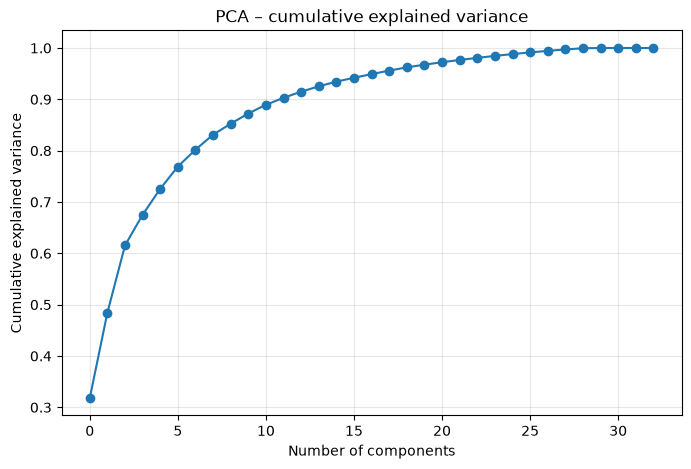

In [12]:
###################
#PCA
##################

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

#Explained variance
explained_variance = pca.explained_variance_ratio_

for i, variance in enumerate(explained_variance[:10], start=1):
    print(f"PC{i}: {variance:.2%}")

#plot cumulative explained variance

plt.figure(figsize=(8, 5))

plt.plot(
    np.cumsum(explained_variance),
    marker="o"
)

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA – cumulative explained variance")
plt.grid(alpha=0.3)

plt.show()

#A principal component (PCA) is not one of your original variables. It is a weighted combination of your 37 variables.
#PC1 explains 31.82%
#That means the direction in your 37-dimensional feature space with the largest amount of variation between stations accounts for about 32% of the total variance.

#That's quite substantial.

#PC2 captures another 16.64%, and PC3 another 13.09%.

#Together:

#31.82+16.64+13.09=61.55%
#So three dimensions capture about 61.6% of the variation in your original 37-dimensional dataset.

#-----------
#Graph
#-----------

#It shows How much of the original variation is retained if I keep the first N principal components?

#The first few PCs are doing a lot of work.

#The later PCs each contribute relatively little.

#THE ELBOW IS AROUND 3 OR 4 

#The first few PCs are doing a lot of work.

#The later PCs each contribute relatively little.

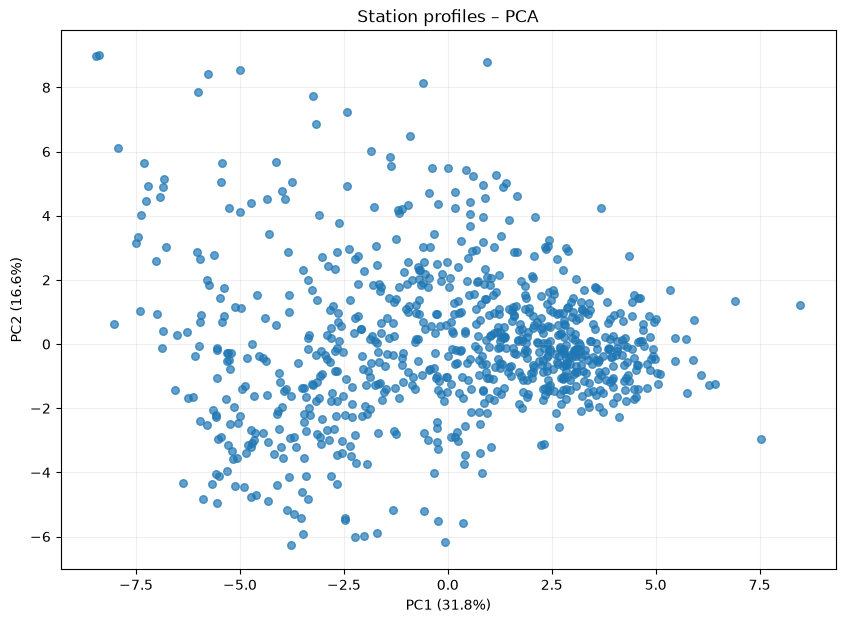

In [13]:
#Visualize stations in PCA space
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.7,
    s=30
)

plt.xlabel(f"PC1 ({explained_variance[0]:.1%})")
plt.ylabel(f"PC2 ({explained_variance[1]:.1%})")
plt.title("Station profiles – PCA")
plt.grid(alpha=0.2)

plt.show()

In [29]:
####################33
#To interpret pca components
####################3

#Get loadings
loadings = pl.DataFrame({
    "feature": feature_columns,
    "PC1": pca.components_[0].tolist(),
    "PC2": pca.components_[1].tolist(),
    "PC3": pca.components_[2].tolist(),
})

#sort PC1
print(
    loadings
    .sort("PC1", descending=True)
)

#And separately look at the largest absolute contributions:
pc1 = (
    loadings
    .with_columns(
        pl.col("PC1").abs().alias("abs_PC1")
    )
    .sort("abs_PC1", descending=True)
)

print(pc1)

#and pc2
pc2 = (
    loadings
    .with_columns(
        pl.col("PC2").abs().alias("abs_PC2")
    )
    .sort("abs_PC2", descending=True)
)

print(pc2)

#and pc3
pc3 = (
    loadings
    .with_columns(
        pl.col("PC3").abs().alias("abs_PC3")
    )
    .sort("abs_PC3", descending=True)
)

print(pc3)

#A loading tells you how strongly an original feature contributes to a principal component.

#PC1 appears to be a temporal/commuting dimension
#PC1 Morning vs evening usage profile

#PC2 seems to be capturing night-time activity.
#PC2 Night-time usage intensity

#PC3 appears to be another temporal dimension
#PC3 midday/early-afternoon activity (and weekend?)


#PC is not causality, is more association, so we can say
#"PC1 is strongly associated with morning-rush and early-hour activity."

#Or better
#PC1 captures the main daily timing orientation of station activity, contrasting morning activity with afternoon/evening activity.


shape: (33, 4)
┌────────────────────┬───────────┬───────────┬───────────┐
│ feature            ┆ PC1       ┆ PC2       ┆ PC3       │
│ ---                ┆ ---       ┆ ---       ┆ ---       │
│ str                ┆ f64       ┆ f64       ┆ f64       │
╞════════════════════╪═══════════╪═══════════╪═══════════╡
│ morning_rush_ratio ┆ 0.2838    ┆ 0.069267  ┆ -0.084499 │
│ 8_hours            ┆ 0.266269  ┆ 0.066521  ┆ -0.087963 │
│ 9_hours            ┆ 0.250866  ┆ 0.051614  ┆ 0.002884  │
│ 7_hours            ┆ 0.235327  ┆ 0.06213   ┆ -0.113324 │
│ 10_hours           ┆ 0.23004   ┆ 0.010204  ┆ 0.136954  │
│ …                  ┆ …         ┆ …         ┆ …         │
│ 16_hours           ┆ -0.218747 ┆ -0.198274 ┆ 0.077725  │
│ 17_hours           ┆ -0.229707 ┆ -0.168363 ┆ -0.134929 │
│ 19_hours           ┆ -0.247561 ┆ 0.014965  ┆ -0.042302 │
│ 18_hours           ┆ -0.250738 ┆ -0.096537 ┆ -0.152083 │
│ evening_rush_ratio ┆ -0.264947 ┆ -0.121398 ┆ -0.137247 │
└────────────────────┴───────────┴───────

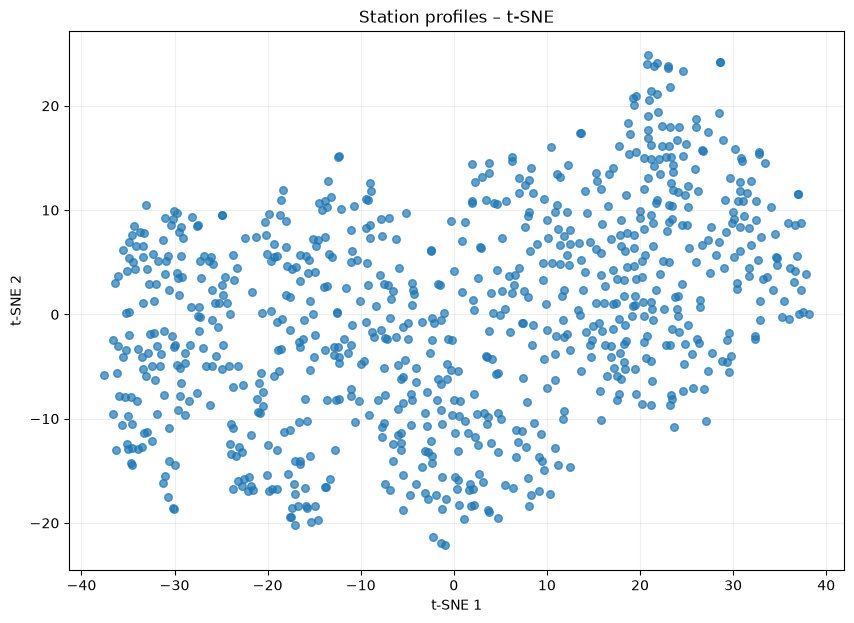

In [27]:
#########################33
#Non linear dimension reduction: t-SNE
###########################

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_scaled)

#plot
plt.figure(figsize=(10, 7))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    s=30,
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Station profiles – t-SNE")
plt.grid(alpha=0.2)

plt.show()

#T-sne tries to do: stations that are close/similar in the original 33-dimensional space tend to remain close together in the 2D map.
#So your t-SNE plot is essentially a map of station similarity.
#If two dots are close together: Their station profiles are relatively similar.
#If two dots are far apart: Their station profiles are relatively different.
#t-SNE is mainly good at showing: local neighbourhood structure

#In the graph: there are not very clear separated groups, maybe there are 3 or 4 different clouds?
#also, it doesnt seem to be a specially dense region nor isolated points

/home/julian/Documents/dauphine/troisieme_module/unsupervised_learning/Project/.env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


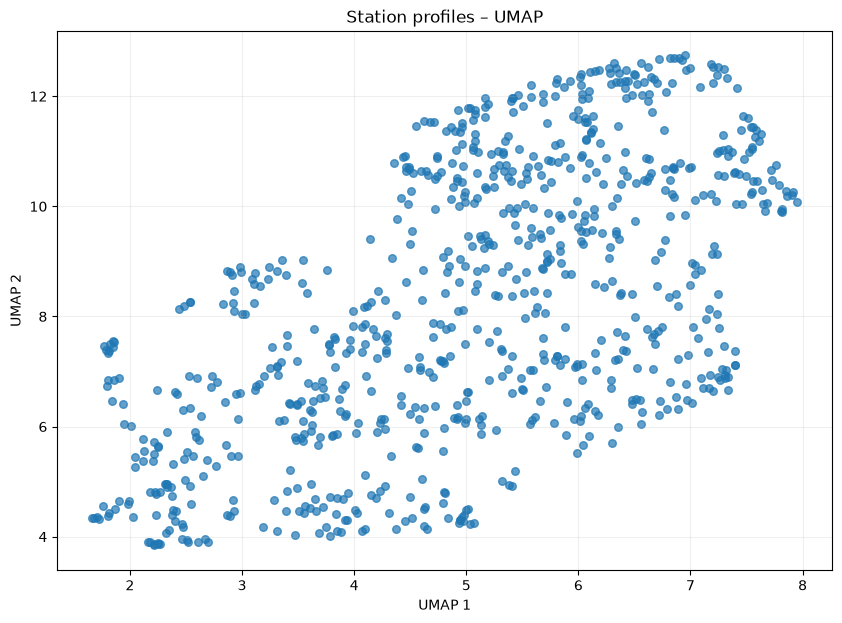

In [17]:
#And using umap
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=30,
    alpha=0.7
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Station profiles – UMAP")
plt.grid(alpha=0.2)

plt.show()

#UMAP = Uniform Manifold Approximation and Projection.
#The basic idea is: "If the 33-dimensional station profiles have some underlying structure, can I represent that structure in 2 dimensions while keeping similar stations close together?"

#In this graph you interpret the relationships between points/regions. like for t-sne

#Here i dont see different clear groups, it looks more like a continous cloud which could mean that station behaviour changes gradually rather than forming naturally separated groups.

#UMAP was used as a nonlinear dimensionality-reduction technique to explore the structure of the station profiles. Unlike PCA, the two UMAP dimensions do not have a direct interpretation in terms of the original variables. 
#Instead, the projection is interpreted in terms of neighbourhood relationships, where nearby stations represent profiles with greater similarity. 
#The resulting projection was used as an exploratory visualisation and not as the basis for determining the number of clusters.

In [18]:
####################3
#Identify natural groups
######################

#using K-means
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    results.append((k, score))

print(results)

#K-means finds its best separation at k = 2, but the silhouette score of 0.245 is relatively weak. This suggests that there are at most two broad groups in your data, but the station profiles do not naturally separate into very distinct clusters.

#since kmeans will always form groups we can say that Among the values of k tested, a two-cluster solution provides the strongest separation according to the silhouette criterion.

#current hypothesis:
#The 822 London stations do not form a set of sharply separated behavioural categories. Instead, station usage appears to vary along several continuous temporal dimensions, with morning/evening activity, night-time activity,
#and weekend/midday activity being the strongest sources of variation. K-means identifies two broad groups as the best partition according to silhouette score, but the relatively low silhouette value indicates substantial overlap between the groups.

[(2, 0.24530580253118367), (3, 0.23384166877914897), (4, 0.19389628583512414), (5, 0.16301049140915735), (6, 0.15963008902839487), (7, 0.12186342571891991), (8, 0.1224966378614129), (9, 0.12415344765224942), (10, 0.1290402553472237)]


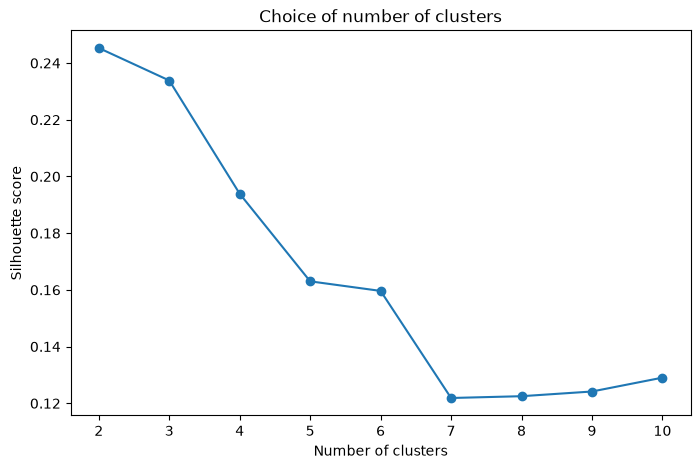

In [19]:
ks = [x[0] for x in results]
scores = [x[1] for x in results]

plt.figure(figsize=(8, 5))

plt.plot(ks, scores, marker="o")

plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Choice of number of clusters")

plt.show()
#THIS IS NOT THE ELBOW METHOD

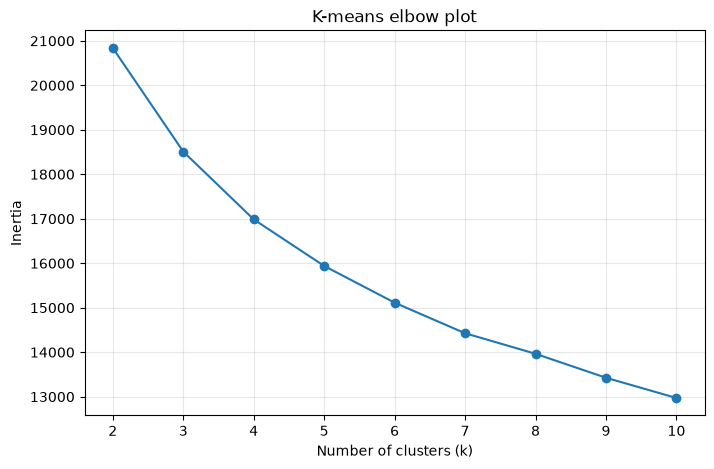

In [30]:
######################
# Inertia - Elbow method
######################
inertias = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_scaled)

    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertias,
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-means elbow plot")
plt.grid(alpha=0.3)

plt.show()

#It shows a smooth curve, which again indicates that there isn't a particularly natural number of clusters

In [31]:
cluster_results = {}

for k in [2, 3, 4, 5, 6]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    cluster_results[k] = labels


for k, labels in cluster_results.items():

    counts = np.bincount(labels)

    print(f"\nk={k}")
    print(counts)

#this gives us the number of stations that each cluster would have based on the k number we set. If we transform to percentage:


#k	Cluster sizes	            Approx. percentages
#2	295, 527	                35.9%, 64.1%
#3	148, 447, 227	            18.0%, 54.4%, 27.6%
#4	145, 131, 378, 168	        17.6%, 15.9%, 46.0%, 20.4%
#5	212, 159, 323, 57, 71	    25.8%, 19.3%, 39.3%, 6.9%, 8.6%
#6	332, 173, 66, 99, 111, 41	40.4%, 21.0%, 8.0%, 12.0%, 13.5%, 5.0%

#What seems to be happening is that there is a large population of fairly similar stations, plus smaller groups that are progressively being separated from it as you increase k


k=2
[295 527]

k=3
[148 447 227]

k=4
[145 131 378 168]

k=5
[212 159 323  57  71]

k=6
[332 173  66  99 111  41]


In [36]:
#----------
#Calculate cluster profiles
#----------

for k in [2, 3, 4]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    profiles = stations.with_columns(
        pl.Series("cluster", labels.tolist())
    )

    cluster_means = (
        profiles
        .group_by("cluster")
        .agg([
            pl.col(feature).mean().alias(feature)
            for feature in feature_columns
        ])
        .sort("cluster")
    )

    print(f"\n===== k={k} =====")
    print(cluster_means)






===== k=2 =====
shape: (2, 34)
┌─────────┬─────────────┬─────────────┬────────────┬───┬──────────┬──────────┬──────────┬──────────┐
│ cluster ┆ mean_durati ┆ median_dura ┆ std_durati ┆ … ┆ 20_hours ┆ 21_hours ┆ 22_hours ┆ 23_hours │
│ ---     ┆ on          ┆ tion        ┆ on         ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ i64     ┆ ---         ┆ ---         ┆ ---        ┆   ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
│         ┆ f64         ┆ f64         ┆ f64        ┆   ┆          ┆          ┆          ┆          │
╞═════════╪═════════════╪═════════════╪════════════╪═══╪══════════╪══════════╪══════════╪══════════╡
│ 0       ┆ 1.6378e6    ┆ 851814.0050 ┆ 2.6336e7   ┆ … ┆ 0.050903 ┆ 0.037622 ┆ 0.030008 ┆ 0.019112 │
│         ┆             ┆ 85          ┆            ┆   ┆          ┆          ┆          ┆          │
│ 1       ┆ 1.4633e6    ┆ 774794.5569 ┆ 2.3636e7   ┆ … ┆ 0.034731 ┆ 0.025286 ┆ 0.019974 ┆ 0.012556 │
│         ┆             ┆ 26          ┆            ┆   ┆   

In [39]:
# cluster centroids in standardised units.

for k in [2, 3, 4]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    kmeans.fit(X_scaled)

    centroid_df = pl.DataFrame(
        kmeans.cluster_centers_.tolist(),
        schema=feature_columns
    ).with_row_index("cluster")

    print(f"\n===== k={k} =====")
    print(centroid_df)



===== k=2 =====
shape: (2, 34)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ cluster ┆ mean_durat ┆ median_du ┆ std_durat ┆ … ┆ 20_hours  ┆ 21_hours  ┆ 22_hours  ┆ 23_hours  │
│ ---     ┆ ion        ┆ ration    ┆ ion       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ u32     ┆ ---        ┆ ---       ┆ ---       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
│         ┆ f64        ┆ f64       ┆ f64       ┆   ┆           ┆           ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0       ┆ 0.129442   ┆ 0.283778  ┆ 0.053643  ┆ … ┆ 0.715939  ┆ 0.611485  ┆ 0.47914   ┆ 0.455368  │
│ 1       ┆ -0.072458  ┆ -0.158851 ┆ -0.030028 ┆ … ┆ -0.400763 ┆ -0.342292 ┆ -0.268209 ┆ -0.254903 │
└─────────┴────────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘

===== k=3 =====
shape: (3, 34)
┌─────────┬────────────┬───

/tmp/ipykernel_13442/1329124880.py:13: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  centroid_df = pl.DataFrame(
/tmp/ipykernel_13442/1329124880.py:13: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  centroid_df = pl.DataFrame(
/tmp/ipykernel_13442/1329124880.py:13: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  centroid_df = pl.DataFrame(


In [44]:
#Features that distinguish clusters
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

kmeans.fit(X_scaled)

centroids = kmeans.cluster_centers_

differences = pl.DataFrame({
    "feature": feature_columns,
    "difference": (centroids[0] - centroids[1]).tolist(),
}).with_columns(
    pl.col("difference").abs().alias("absolute_difference")
).sort(
    "absolute_difference",
    descending=True
)

print(differences)

#The main dimension separating your stations is the time of day: morning/commuter activity versus evening activity.
#tentative names: 
#Cluster 0 — Evening-oriented stations
#Characteristics:
#  - higher evening_rush_ratio
#  - higher 18:00 activity
#  - higher 20:00–23:00 activity
#  - relatively lower morning activity

#Cluster 1 — Morning-oriented stations
#Characteristics:
#  - higher morning_rush_ratio
#  - higher 08:00 activity
#  - higher 09:00 activity
#  - relatively lower evening activity




#The station profiles appear to be structured primarily along a temporal dimension, contrasting stations with relatively stronger morning activity against those with relatively stronger evening activity.
#However, the absence of a clear elbow, the relatively low silhouette scores, and the lack of clearly separated groups in PCA suggest that this behaviour is better interpreted as a continuum rather than as a set of sharply distinct station types.

shape: (33, 3)
┌────────────────────┬────────────┬─────────────────────┐
│ feature            ┆ difference ┆ absolute_difference │
│ ---                ┆ ---        ┆ ---                 │
│ str                ┆ f64        ┆ f64                 │
╞════════════════════╪════════════╪═════════════════════╡
│ evening_rush_ratio ┆ 1.625462   ┆ 1.625462            │
│ morning_rush_ratio ┆ -1.623489  ┆ 1.623489            │
│ 8_hours            ┆ -1.510471  ┆ 1.510471            │
│ 9_hours            ┆ -1.508205  ┆ 1.508205            │
│ 18_hours           ┆ 1.506246   ┆ 1.506246            │
│ …                  ┆ …          ┆ …                   │
│ mean_duration      ┆ 0.2019     ┆ 0.2019              │
│ 2_hours            ┆ 0.108117   ┆ 0.108117            │
│ 3_hours            ┆ -0.088879  ┆ 0.088879            │
│ std_duration       ┆ 0.083671   ┆ 0.083671            │
│ 13_hours           ┆ 0.041136   ┆ 0.041136            │
└────────────────────┴────────────┴─────────────────────┘

In [45]:
#Select K value after analysis
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_scaled)

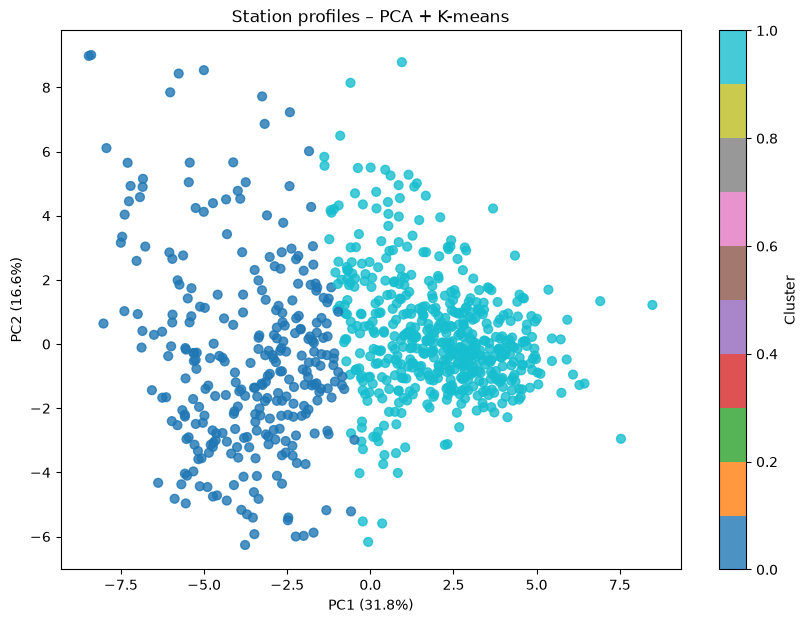

In [46]:
################3
#Color PCA plot by cluster
#################

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap="tab10",
    s=40,
    alpha=0.8
)

plt.xlabel(f"PC1 ({explained_variance[0]:.1%})")
plt.ylabel(f"PC2 ({explained_variance[1]:.1%})")
plt.title("Station profiles – PCA + K-means")

plt.colorbar(scatter, label="Cluster")

plt.show()

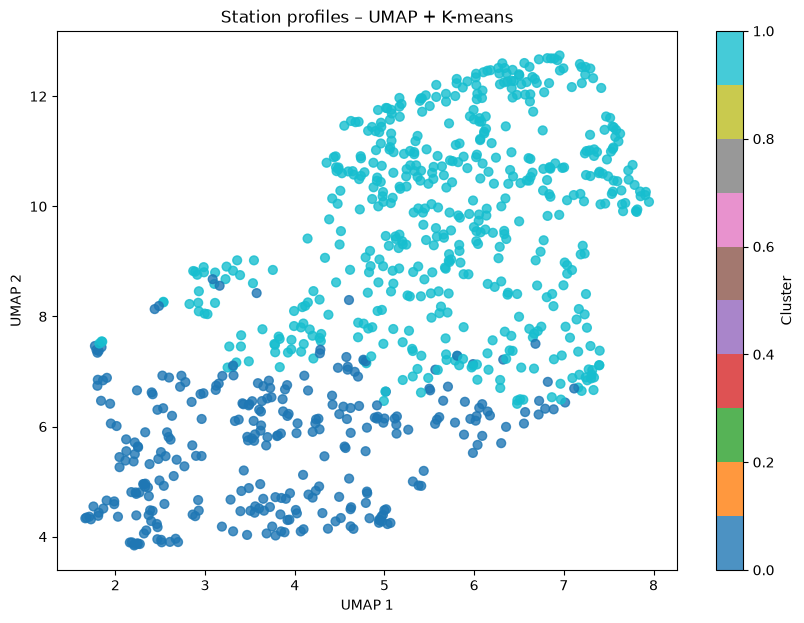

In [47]:
#and same for umap
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=labels,
    cmap="tab10",
    s=40,
    alpha=0.8
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Station profiles – UMAP + K-means")

plt.colorbar(scatter, label="Cluster")

plt.show()


In [59]:
##############
#Find atypical or isolated stations
###############

#-------------
# distance from the cluster centroid
#-------------
cluster_thresholds = (
    stations_analysis
    .group_by("cluster")
    .agg(
        pl.col("distance_to_cluster_center")
        .quantile(0.99)
        .alias("outlier_threshold")
    )
)

outliers = (
    stations_analysis
    .join(cluster_thresholds, on="cluster")
    .filter(
        pl.col("distance_to_cluster_center")
        >= pl.col("outlier_threshold")
    )
    .sort("distance_to_cluster_center", descending=True)
)

print(
    outliers.select([
        "station",
        "cluster",
        "distance_to_cluster_center",
        "outlier_threshold"
    ])
)


shape: (10, 4)
┌─────────┬─────────┬────────────────────────────┬───────────────────┐
│ station ┆ cluster ┆ distance_to_cluster_center ┆ outlier_threshold │
│ ---     ┆ ---     ┆ ---                        ┆ ---               │
│ i64     ┆ i64     ┆ f64                        ┆ f64               │
╞═════════╪═════════╪════════════════════════════╪═══════════════════╡
│ 0       ┆ 1       ┆ 16.171636                  ┆ 13.462145         │
│ 0       ┆ 1       ┆ 15.969747                  ┆ 13.462145         │
│ 200009  ┆ 1       ┆ 15.880821                  ┆ 13.462145         │
│ 2635    ┆ 1       ┆ 15.413622                  ┆ 13.462145         │
│ 200233  ┆ 0       ┆ 15.037739                  ┆ 11.60738          │
│ 200089  ┆ 1       ┆ 13.721505                  ┆ 13.462145         │
│ 1219444 ┆ 1       ┆ 13.462145                  ┆ 13.462145         │
│ 1101    ┆ 0       ┆ 12.669408                  ┆ 11.60738          │
│ 2660    ┆ 0       ┆ 11.767088                  ┆ 11.60738   

In [60]:
print(
    stations_analysis.select([
        pl.col("distance_to_cluster_center").quantile(0.50).alias("median"),
        pl.col("distance_to_cluster_center").quantile(0.75).alias("q75"),
        pl.col("distance_to_cluster_center").quantile(0.90).alias("q90"),
        pl.col("distance_to_cluster_center").quantile(0.95).alias("q95"),
        pl.col("distance_to_cluster_center").quantile(0.99).alias("q99"),
    ])
)

#"The stations identified as atypical are those in the upper 1% of distances to their cluster centroid."

shape: (1, 5)
┌──────────┬──────────┬──────────┬──────────┬───────────┐
│ median   ┆ q75      ┆ q90      ┆ q95      ┆ q99       │
│ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---       │
│ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64       │
╞══════════╪══════════╪══════════╪══════════╪═══════════╡
│ 4.009103 ┆ 5.404875 ┆ 7.206666 ┆ 8.604757 ┆ 12.669408 │
└──────────┴──────────┴──────────┴──────────┴───────────┘


In [65]:
#---------------------
#Isolation forest
#---------------------
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

outlier_labels = iso.fit_predict(X_scaled)

stations_iforest = stations.with_columns(
    pl.Series("isolation_outlier", outlier_labels.tolist())
)

outliers_iforest = (
    stations_iforest
    .filter(pl.col("isolation_outlier") == -1)
)

print(
    outliers_iforest.select("station")
)



shape: (9, 1)
┌─────────┐
│ station │
│ ---     │
│ i64     │
╞═════════╡
│ 0       │
│ 1072    │
│ 2635    │
│ 2692    │
│ 1219444 │
│ 200233  │
│ 0       │
│ 1101    │
│ 1158    │
└─────────┘


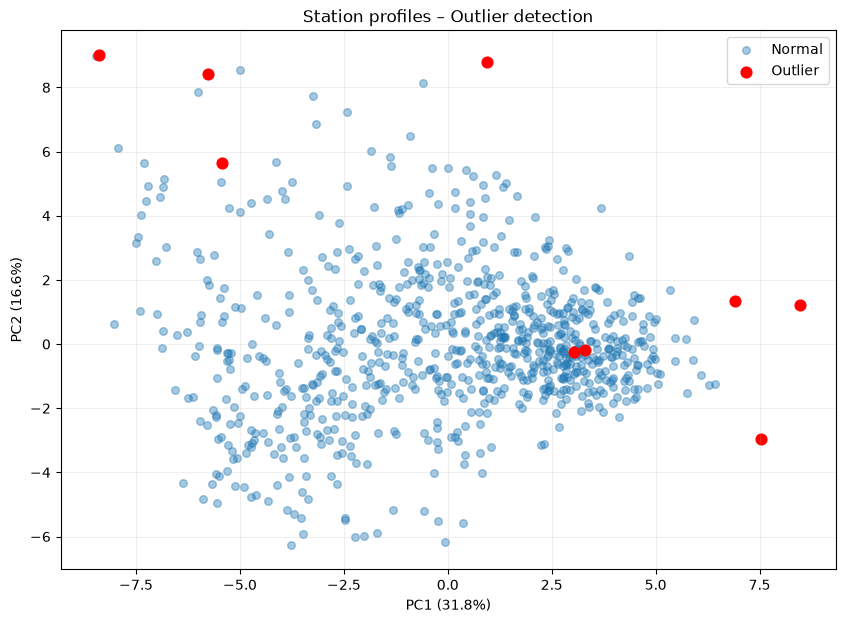

In [66]:
#---------------
#Outliers graph
#---------------

plt.figure(figsize=(10, 7))

normal = outlier_labels == 1
outlier = outlier_labels == -1

plt.scatter(
    X_pca[normal, 0],
    X_pca[normal, 1],
    alpha=0.4,
    s=30,
    label="Normal"
)

plt.scatter(
    X_pca[outlier, 0],
    X_pca[outlier, 1],
    color="red",
    s=60,
    label="Outlier"
)

plt.xlabel(f"PC1 ({explained_variance[0]:.1%})")
plt.ylabel(f"PC2 ({explained_variance[1]:.1%})")
plt.title("Station profiles – Outlier detection")
plt.legend()
plt.grid(alpha=0.2)

plt.show()


In [75]:
#--------------------------
#Very low or high activity
#--------------------------
#check distribution
print(stations.select([
    pl.col("n_departures").quantile(0.01).alias("p01"),
    pl.col("n_departures").quantile(0.05).alias("p05"),
    pl.col("n_departures").median().alias("median"),
    pl.col("n_departures").quantile(0.95).alias("p95"),
    pl.col("n_departures").quantile(0.99).alias("p99"),
]))

#Identify station in the top 1% of departures
q01_dep = stations["n_departures"].quantile(0.01)
q99_dep = stations["n_departures"].quantile(0.99)

activity_outliers_dep = stations.filter(
    (pl.col("n_departures") <= q01_dep) |
    (pl.col("n_departures") >= q99_dep)
)

#Identify station in the top 1% of arrivals
q01_arr = stations["n_arrivals"].quantile(0.01)
q99_arr = stations["n_arrivals"].quantile(0.99)

activity_outliers_arr = stations.filter(
    (pl.col("n_arrivals") <= q01_arr) |
    (pl.col("n_arrivals") >= q99_arr)
)

# Total activity = departures + arrivals
stations = stations.with_columns(
    (
        pl.col("n_departures") + pl.col("n_arrivals")
    ).alias("total_activity")
)

# 1st and 99th percentiles
q01_activity = stations["total_activity"].quantile(0.01)
q99_activity = stations["total_activity"].quantile(0.99)

# Identify unusually low or high activity stations
activity_outliers = stations.filter(
    (pl.col("total_activity") <= q01_activity) |
    (pl.col("total_activity") >= q99_activity)
)



print(
    activity_outliers.select([
        "station",
        "n_departures",
        "n_arrivals",
        "total_activity"
    ])
)


shape: (1, 5)
┌───────┬────────┬────────┬─────────┬─────────┐
│ p01   ┆ p05    ┆ median ┆ p95     ┆ p99     │
│ ---   ┆ ---    ┆ ---    ┆ ---     ┆ ---     │
│ f64   ┆ f64    ┆ f64    ┆ f64     ┆ f64     │
╞═══════╪════════╪════════╪═════════╪═════════╡
│ 841.0 ┆ 2950.0 ┆ 9550.0 ┆ 21933.0 ┆ 32640.0 │
└───────┴────────┴────────┴─────────┴─────────┘
shape: (18, 4)
┌───────────┬──────────────┬────────────┬────────────────┐
│ station   ┆ n_departures ┆ n_arrivals ┆ total_activity │
│ ---       ┆ ---          ┆ ---        ┆ ---            │
│ i64       ┆ i64          ┆ i64        ┆ i64            │
╞═══════════╪══════════════╪════════════╪════════════════╡
│ 0         ┆ 0            ┆ 607        ┆ 607            │
│ 1075      ┆ 42737        ┆ 36931      ┆ 79668          │
│ 1072      ┆ 53880        ┆ 50563      ┆ 104443         │
│ 2635      ┆ 37           ┆ 27         ┆ 64             │
│ 200083444 ┆ 488          ┆ 554        ┆ 1042           │
│ …         ┆ …            ┆ …          ┆ …  

In [68]:
#--------------------
#Extreme departures/arrivales ration
#--------------------

stations_ratio = stations.with_columns(
    (
        pl.col("n_departures") /
        (pl.col("n_departures") + pl.col("n_arrivals"))
    ).alias("departure_share")
)

print(
    stations_ratio
    .sort("departure_share")
    .select([
        "station",
        "n_departures",
        "n_arrivals",
        "departure_share"
    ])
    .head(10)
)

print(
    stations_ratio
    .sort("departure_share", descending=True)
    .select([
        "station",
        "n_departures",
        "n_arrivals",
        "departure_share"
    ])
    .head(10)
)

#close to 0.5 → balanced
#close to 1 → mostly departures
#close to 0 → mostly arrivals

shape: (10, 4)
┌─────────┬──────────────┬────────────┬─────────────────┐
│ station ┆ n_departures ┆ n_arrivals ┆ departure_share │
│ ---     ┆ ---          ┆ ---        ┆ ---             │
│ i64     ┆ i64          ┆ i64        ┆ f64             │
╞═════════╪══════════════╪════════════╪═════════════════╡
│ 0       ┆ 0            ┆ 607        ┆ 0.0             │
│ 0       ┆ 0            ┆ 199        ┆ 0.0             │
│ 200226  ┆ 10824        ┆ 18015      ┆ 0.375325        │
│ 982     ┆ 19593        ┆ 30817      ┆ 0.388673        │
│ 2688    ┆ 6265         ┆ 9062       ┆ 0.408756        │
│ 200072  ┆ 10838        ┆ 15551      ┆ 0.410701        │
│ 1067    ┆ 28981        ┆ 40483      ┆ 0.417209        │
│ 1061    ┆ 4564         ┆ 6352       ┆ 0.418102        │
│ 3431    ┆ 5616         ┆ 7679       ┆ 0.422414        │
│ 200253  ┆ 7301         ┆ 9965       ┆ 0.422854        │
└─────────┴──────────────┴────────────┴─────────────────┘
shape: (10, 4)
┌─────────┬──────────────┬────────────┬───

In [69]:
#----------------
#atypical hour profile
#----------------
stations_pca = stations.with_columns([
    pl.Series("PC1", X_pca[:, 0].tolist()),
    pl.Series("PC2", X_pca[:, 1].tolist()),
    pl.Series("PC3", X_pca[:, 2].tolist())
])
stations_pca.sort("PC1").select([
    "station",
    "PC1",
    "PC2",
    "PC3"
]).head(10)
stations_pca.sort("PC1", descending=True).select([
    "station",
    "PC1",
    "PC2",
    "PC3"
]).head(10)


#Which stations have an unusual distribution of activity throughout the day?

#And you already have the tools to do this.

#Your PCA showed:

#PC1 ≈ morning vs evening behaviour
#PC2 ≈ night/early morning behaviour
#PC3 ≈ midday/weekend behaviour
#So a station with an extreme PCA score can potentially be considered temporally atypical.


station,PC1,PC2,PC3
i64,f64,f64,f64
1072,8.481897,1.220548,-9.009296
2635,7.535486,-2.953436,4.765172
2692,6.912331,1.338149,-6.458327
200170,6.439182,-1.230568,-1.747176
200007,6.286888,-1.275968,-2.495284
200023,6.094048,-0.94982,-1.878438
200194,5.922879,0.758089,-0.025944
3434,5.903701,-0.481198,0.348759
200177,5.744905,-1.518578,-0.106274


In [54]:
#################33
#Make clusters interpretables
##################

cluster_summary = (
    stations_analysis
    .group_by("cluster")
    .agg([
        pl.col(c).mean().alias(c)
        for c in feature_columns
    ])
)

print(cluster_summary)



shape: (2, 34)
┌─────────┬─────────────┬─────────────┬────────────┬───┬──────────┬──────────┬──────────┬──────────┐
│ cluster ┆ mean_durati ┆ median_dura ┆ std_durati ┆ … ┆ 20_hours ┆ 21_hours ┆ 22_hours ┆ 23_hours │
│ ---     ┆ on          ┆ tion        ┆ on         ┆   ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ i64     ┆ ---         ┆ ---         ┆ ---        ┆   ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
│         ┆ f64         ┆ f64         ┆ f64        ┆   ┆          ┆          ┆          ┆          │
╞═════════╪═════════════╪═════════════╪════════════╪═══╪══════════╪══════════╪══════════╪══════════╡
│ 1       ┆ 1.4633e6    ┆ 774794.5569 ┆ 2.3636e7   ┆ … ┆ 0.034731 ┆ 0.025286 ┆ 0.019974 ┆ 0.012556 │
│         ┆             ┆ 26          ┆            ┆   ┆          ┆          ┆          ┆          │
│ 0       ┆ 1.6378e6    ┆ 851814.0050 ┆ 2.6336e7   ┆ … ┆ 0.050903 ┆ 0.037622 ┆ 0.030008 ┆ 0.019112 │
│         ┆             ┆ 85          ┆            ┆   ┆          ┆         